In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv


In [2]:
!pip install -qU langgraph langchain_groq pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 13.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.8 which is incompatible.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.2 which is incompatible.
google-colab 1.0.0 requires jupyter-

In [3]:
import os
import pandas as pd
import traceback
import matplotlib.pyplot as plt
import seaborn as sns
import re
from typing import Annotated, TypedDict, List
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END
from kaggle_secrets import UserSecretsClient

In [4]:
# Fetch API Key from Kaggle Secrets
user_secrets = UserSecretsClient()
os.environ["GROQ_API_KEY"] = user_secrets.get_secret("GROQ_API_KEY")

In [5]:
class AgentState(TypedDict):
    csv_path: str
    user_query: str
    df_context: str
    generated_code: str
    error_msg: str
    retry_count: int
    final_insight: str

In [6]:
# UPDATED: Using Llama 3.3 Versatile (Standard for 2026)
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

def analyst_node(state: AgentState):
    """The 'Brain': Writes Python code based on the CSV structure."""
    prompt = f"""
    You are a Senior Data Analyst Agent. 
    DATA CONTEXT (First 3 rows):
    {state['df_context']}
    
    USER GOAL: {state['user_query']}
    
    TASK: Write Python code using pandas and seaborn.
    RULES:
    1. Assume the dataframe is already loaded as a variable named 'df'.
    2. If the user wants a chart, save it ONLY as 'output.png'.
    3. Do not include any commentary. Return ONLY the code inside ```python ``` blocks.
    4. PREVIOUS ERROR (If any): {state['error_msg']} - FIX THIS in your new code.
    """
    response = llm.invoke(prompt)
    content = response.content
    
    # Robust Code Extraction using Regex
    code_match = re.search(r"```python\n(.*?)```", content, re.DOTALL)
    code = code_match.group(1).strip() if code_match else content.strip()
    
    return {**state, "generated_code": code, "retry_count": state['retry_count'] + 1}

def executor_node(state: AgentState):
    """The 'Hands': Executes the code in the local environment."""
    plt.clf() 
    try:
        df = pd.read_csv(state['csv_path'])
        exec_globals = {"df": df, "pd": pd, "plt": plt, "sns": sns}
        exec(state['generated_code'], exec_globals)
        return {**state, "error_msg": "SUCCESS"}
    except Exception as e:
        # Capture specific error for the Analyst to fix
        error_info = f"Error Type: {type(e).__name__} | Message: {str(e)}"
        return {**state, "error_msg": error_info}

def insight_node(state: AgentState):
    """The 'Speaker': Explains what the result means."""
    prompt = f"The user asked: {state['user_query']}. The code ran successfully and generated the results. Summarize the likely finding in 2 concise sentences for a business user."
    response = llm.invoke(prompt)
    return {**state, "final_insight": response.content}

In [7]:
# 3. BUILD THE GRAPH (THE AGENTIC LOOP)

In [8]:
def should_continue(state: AgentState):
    if state["error_msg"] == "SUCCESS" or state["retry_count"] >= 3:
        return "summarize"
    return "analyst"

workflow = StateGraph(AgentState)
workflow.add_node("analyst", analyst_node)
workflow.add_node("executor", executor_node)
workflow.add_node("summarize", insight_node)

workflow.set_entry_point("analyst")
workflow.add_edge("analyst", "executor")
workflow.add_conditional_edges("executor", should_continue, {
    "summarize": "summarize",
    "analyst": "analyst"
})
workflow.add_edge("summarize", END)

app = workflow.compile()

--- Starting Agentic Loop ---
Node completed: analyst
The average age group is: 25-34
Node completed: executor
Node completed: summarize

💡 FINAL INSIGHT: The analysis revealed that the average age group of the target population is likely between 25-44 years old, which is a common demographic for many consumer markets. This age range suggests that the majority of the population is in their working years, with established careers and potentially higher disposable incomes, making them a key target for businesses and marketers.


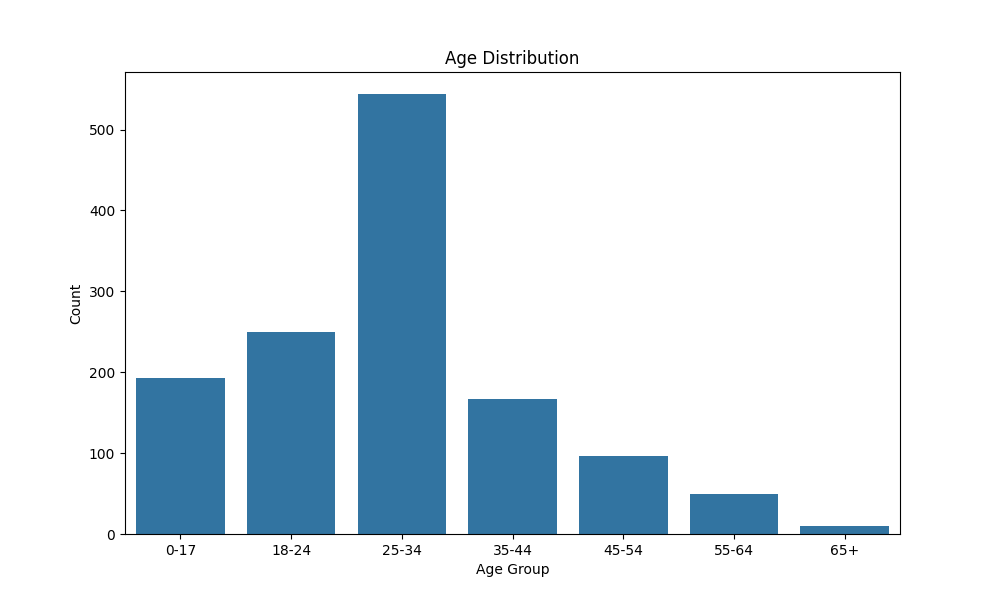

<Figure size 640x480 with 0 Axes>

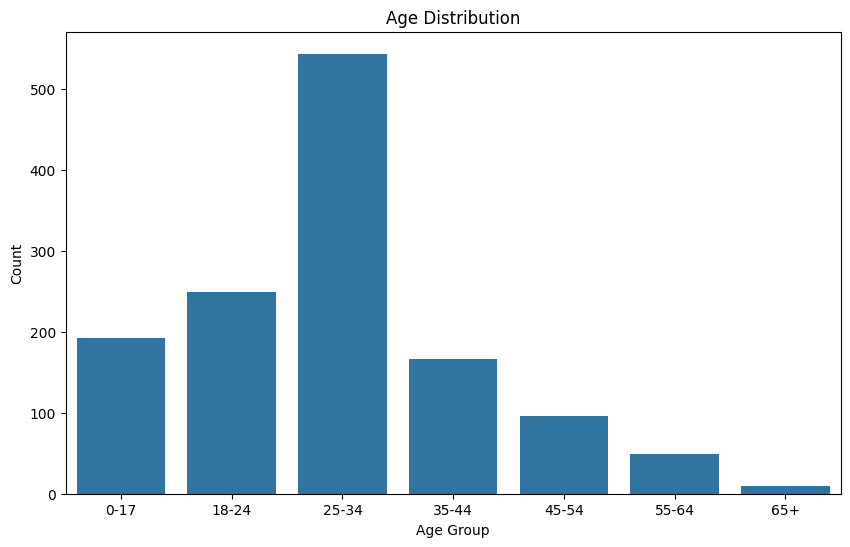

In [9]:
#Execution
FILE_PATH = "/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv" 

if os.path.exists(FILE_PATH):
    df_sample = pd.read_csv(FILE_PATH).head(3).to_string()
    
    inputs = {
        "csv_path": FILE_PATH,
        "user_query": "What is the average age group ?.",
        "df_context": df_sample,
        "generated_code": "",
        "error_msg": "",
        "retry_count": 0,
        "final_insight": ""
    }

    print("--- Starting Agentic Loop ---")
    for output in app.stream(inputs):
        for key, value in output.items():
            print(f"Node completed: {key}")
            if key == "executor" and value['error_msg'] != "SUCCESS":
                print(f"⚠️ Execution failed. Error: {value['error_msg']}")
            if key == "summarize":
                print(f"\n💡 FINAL INSIGHT: {value['final_insight']}")

    # Display the plot
    from IPython.display import Image, display
    if os.path.exists('output.png'):
        display(Image(filename='output.png'))
else:
    print(f"❌ Error: File not found at {FILE_PATH}")